# Index Tracking Simulator — Taiwan Top-30 Basket

**Goal:** Compare Full Replication vs. Optimized Sampling for tracking a
self-defined "Top 30 Taiwan market-cap" basket, measure tracking error, and
estimate rebalance turnover cost.

**Out of scope (by design):** FX hedging, corporate action processing
(dividends/splits/M&A beyond what Adjusted Close already handles),
securities lending, multi-period continuous rebalancing.


## Setup

Standard imports. We use `yfinance` for both price history and market cap
snapshots, `pandas`/`numpy` for the return math, and `matplotlib` for the
tracking error chart later in Step 3.


In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

TODAY = datetime.today()
print("Run date:", TODAY.strftime("%Y-%m-%d"))


Run date: 2026-08-08


## Step 1 — Select the Universe (Top 30 by Market Cap)

Instead of hand-picking a candidate pool of "well-known large caps" (which
risks missing names that have recently grown into the top 30, or including
ones that have fallen out), we compute market cap for the **entire TWSE
listed market** using two free, keyless TWSE OpenAPI endpoints, then rank
and take the top 30 ourselves:

- **`STOCK_DAY_ALL`** — today's (or the most recent trading day's) closing
  price for every listed stock.
- **`t187ap03_L`** — company profile data, including issued common shares
  outstanding, for every listed company.

`Market Cap = Closing Price x Shares Outstanding`, computed per ticker,
then sorted descending. 

**Note:** these endpoints require outbound internet access from wherever
you run this notebook. If your network blocks them, there's a fallback
cell below that reverts to a manually defined candidate pool + `yfinance`
market cap lookups (slower, and only as good as the list you maintain).


In [59]:
import requests
import pandas as pd

resp = requests.get("https://openapi.twse.com.tw/v1/exchangeReport/STOCK_DAY_ALL", timeout=30)
data = resp.json()

print(f"Total count: {len(data)}")
print(f"First row: {data[0]}")          
print(f"Column names: {list(data[0].keys())}")  

df = pd.DataFrame(data)
df.head()        
df.dtypes        

Total count: 1378
First row: {'Date': '1150810', 'Code': '00400A', 'Name': '主動國泰動能高息', 'TradeVolume': '37751808', 'TradeValue': '528954418', 'OpeningPrice': '13.98', 'HighestPrice': '14.12', 'LowestPrice': '13.88', 'ClosingPrice': '13.94', 'Change': '0.2000', 'Transaction': '6729'}
Column names: ['Date', 'Code', 'Name', 'TradeVolume', 'TradeValue', 'OpeningPrice', 'HighestPrice', 'LowestPrice', 'ClosingPrice', 'Change', 'Transaction']


Date            str
Code            str
Name            str
TradeVolume     str
TradeValue      str
OpeningPrice    str
HighestPrice    str
LowestPrice     str
ClosingPrice    str
Change          str
Transaction     str
dtype: object

In [60]:
import requests
import pandas as pd

resp = requests.get("https://openapi.twse.com.tw/v1/opendata/t187ap03_L", timeout=30)
data = resp.json()

print(f"Total count: {len(data)}")
print(f"First row: {data[0]}")           
print(f"Column names: {list(data[0].keys())}")  
     

Total count: 1094
First row: {'出表日期': '1150810', '公司代號': '1101', '公司名稱': '臺灣水泥股份有限公司', '公司簡稱': '台泥', '外國企業註冊地國': '－ ', '產業別': '01', '住址': '台北市中山北路2段113號', '營利事業統一編號': '11913502', '董事長': '張安平', '總經理': '程耀輝', '發言人': '葉毓君', '發言人職稱': '永續長', '代理發言人': '賴家柔', '總機電話': '(02)2531-7099', '成立日期': '19501229', '上市日期': '19620209', '普通股每股面額': '新台幣                 10.0000元', '實收資本額': '77231817420', '私募股數': '0', '特別股': '200000000', '編制財務報表類型': '1', '股票過戶機構': '中國信託商業銀行代理部', '過戶電話': '66365566', '過戶地址': '台北市重慶南路一段83號5樓', '簽證會計師事務所': '勤業眾信聯合會計師事務所', '簽證會計師1': '翁雅玲', '簽證會計師2': '邵志明', '英文簡稱': 'TCC', '英文通訊地址': 'No.113, Sec.2, Zhongshan N. Rd.,Taipei City 104,Taiwan (R.O.C.)', '傳真機號碼': '(02)2531-6529', '電子郵件信箱': 'finance@taiwancement.com', '網址': 'https://www.tccgroupholdings.com/tw/', '已發行普通股數或TDR原股發行股數': '7523181742'}
Column names: ['出表日期', '公司代號', '公司名稱', '公司簡稱', '外國企業註冊地國', '產業別', '住址', '營利事業統一編號', '董事長', '總經理', '發言人', '發言人職稱', '代理發言人', '總機電話', '成立日期', '上市日期', '普通股每股面額', '實收資本額', '私募股數', '特別股', '編制財務報表類型', '

In [27]:
import requests

STOCK_DAY_ALL_URL = "https://openapi.twse.com.tw/v1/exchangeReport/STOCK_DAY_ALL"
COMPANY_PROFILE_URL = "https://openapi.twse.com.tw/v1/opendata/t187ap03_L"

# 1) Whole-market closing prices (today's/most recent trading day)
resp = requests.get(STOCK_DAY_ALL_URL, timeout=30)
resp.raise_for_status()
price_all = pd.DataFrame(resp.json())
price_all = price_all.rename(columns={"Code": "ticker", "ClosingPrice": "close"})
price_all["close"] = pd.to_numeric(price_all["close"], errors="coerce")
price_all = price_all[["ticker", "close"]].dropna()

print(f"Whole-market close prices pulled: {len(price_all)} tickers")
price_all.head()


Whole-market close prices pulled: 1377 tickers


,ticker,close
0,00400A,13.7400
1,00401A,13.2300
2,00402A,9.7500
3,00403A,9.7200
4,00404A,9.3900


In [28]:
# 2) Company profile data (contains issued shares outstanding)
resp2 = requests.get(COMPANY_PROFILE_URL, timeout=30)
resp2.raise_for_status()
profile_all = pd.DataFrame(resp2.json())

SHARES_COL = "已發行普通股數或TDR原股發行股數"
TICKER_COL = "公司代號" 

assert SHARES_COL in profile_all.columns, (
    f"Expected column '{SHARES_COL}' not found. Available columns: "
    f"{list(profile_all.columns)}. The TWSE API may have renamed this field -- "
    f"inspect the printed column list and update SHARES_COL accordingly."
)
assert TICKER_COL in profile_all.columns, (
    f"Expected column '{TICKER_COL}' not found. Available columns: "
    f"{list(profile_all.columns)}."
)

profile_all = profile_all.rename(columns={TICKER_COL: "ticker", SHARES_COL: "shares_outstanding"})
profile_all["shares_outstanding"] = pd.to_numeric(
    profile_all["shares_outstanding"], errors="coerce"
)
profile_all = profile_all[["ticker", "shares_outstanding"]].dropna()

print(f"Company profiles pulled: {len(profile_all)} tickers")
profile_all.head().style.format({"shares_outstanding": "{:,}"})

Company profiles pulled: 1093 tickers


,ticker,shares_outstanding
0,1101,"7,523,181,742"
1,1102,"3,546,562,881"
2,1103,"832,874,553"
3,1104,"686,681,816"
4,1108,"404,738,049"


In [11]:
# 3) Join and compute market cap for the whole market
market_df = price_all.merge(profile_all, on="ticker", how="inner")
market_df["market_cap"] = market_df["close"] * market_df["shares_outstanding"]
market_df = market_df.sort_values("market_cap", ascending=False).set_index("ticker")
market_df["market_cap_bn_TWD"] = market_df["market_cap"] / 1e9

print(f"Matched tickers with both price and shares data: {len(market_df)}") # 1589.TW was de-listed from mid-2026


TOP_N = 30
top30 = market_df.head(TOP_N).copy()
top30["weight"] = top30["market_cap"] / top30["market_cap"].sum()


# yfinance needs the .TW suffix
top30.index = [f"{t}.TW" for t in top30.index]
universe = top30.index.tolist()

print(f"Selected top {TOP_N} tickers by market cap:")
top30[["market_cap_bn_TWD", "weight"]]


Matched tickers with both price and shares data: 1092
Selected top 30 tickers by market cap:


,market_cap_bn_TWD,weight
2330.TW,"61,459.7171",0.5738
2454.TW,"6,255.1921",0.0584
2308.TW,"4,285.9465",0.0400
2317.TW,"3,647.4486",0.0341
3711.TW,"2,615.2848",0.0244
2383.TW,"1,877.6026",0.0175
2881.TW,"1,778.9353",0.0166
2408.TW,"1,576.7441",0.0147
3037.TW,"1,517.3737",0.0142
1303.TW,"1,490.9945",0.0139


## Data Quality Note — `t187ap03_L` Shares Outstanding Discrepancy

**Date checked:** 2026-08-07
**Comparison source:** TWSE official market cap ranking (top 20), https://accessibility.twse.com.tw/zh/listed/ranking.html

### Observation

Cross-checking the top-30 market cap table computed in this notebook against
TWSE's official top-20 market cap ranking page (same date, 8/7 close), most
tickers matched almost exactly. Four tickers showed a meaningful mismatch:

| Ticker | Company | TWSE official (bn TWD) | Notebook calc (bn TWD) | Diff (%) |
|---|---|---:|---:|---:|
| 3037 | Unimicron (欣興) | 1,565.12 | 1,517.37 | **-3.1%** |
| 2408 | Nanya Technology (南亞科) | 1,416.07 | 1,576.74 | **+11.3%** |
| 2382 | Quanta Computer (廣達) | 1,224.07 | 1,151.06 | **-6.0%** |
| 2327 | Yageo (國巨*) | 1,118.59 | 1,111.71 | -0.6% (within rounding) |

All other ~15 tickers matched to within rounding error, confirming the
`close x shares_outstanding` market cap formula and the `price_all` /
`profile_all` join logic are correct. The mismatches are isolated to a few
tickers, not a systematic calculation bug.

### Root cause: confirmed via 3037 (Unimicron)

Pulled 3037's official shareholder distribution table (股權分散表) from MOPS,
which reports an explicit as-of date:

- **Shareholder distribution table** (as of 2026-03-31): total issued
  shares = **1,589,228,785**
- **`t187ap03_L` API** (`shares_outstanding` field, "已發行普通股數或TDR原股發行股數"):
  returned a lower figure, implying approximately **1,540,830,000** shares
  (back-calculated from the market cap ratio: 1,517.37 / 1,565.12 ≈ 0.9695)

Difference: ~48.4 million shares (~3.05%), which matches the observed
-3.1% market cap discrepancy almost exactly.

**Conclusion:** `t187ap03_L`'s shares-outstanding field does not reliably
reflect the most recent share count. It likely lags corporate actions such
as capital increases, private placements, or convertible bond conversions.
Unlike the shareholder distribution table (which explicitly states its
as-of date), `t187ap03_L` only exposes a generic `出表日期` field, which
reflects the API's response timestamp, not the effective date of the
shares-outstanding figure — so staleness in this field cannot be detected
from the API response alone.

### Impact on this project

- Does **not** materially affect the Top-30 universe selection: all four
  flagged tickers remain comfortably within the top 30 regardless of which
  shares figure is used.
- Does introduce a few-percent weight bias for the affected tickers in the
  cap-weighted benchmark — acceptable but worth stating explicitly as a known data limitation rather
  than silently ignoring it.

### Suggested mitigation (not implemented, out of scope for this pass)

- Cross-validate `shares_outstanding` against `實收資本額 / par value` from
  the same `t187ap03_L` response as an internal consistency check.
- For a production-grade version, replace `t187ap03_L` with a data source
  that publishes an explicit as-of date for shares outstanding (e.g. the
  MOPS shareholder distribution table, 股權分散表).

## Step 2 — Build the Benchmark (Cap-Weighted) Return Series

**Adjusted Close vs. Close:** we use `auto_adjust=True` in `yf.download`,
which returns split- and dividend-adjusted prices. Splits *must* be
adjusted or the return series will show fake jumps. Dividends are also
folded in here — equivalent to assuming immediate reinvestment, which is
the standard convention for a Total Return index construction.

**Index construction logic:**

Weights `w_i` are fixed at today's market-cap weights (from Step 1). The
benchmark index level is built as a **fixed-weight buy-and-hold portfolio**
using price relatives:

```
Index_t = Sum_i  w_i x (Price_i,t / Price_i,0)
```

This is mathematically equivalent to buying each stock in proportion to
its market-cap weight on day 0 and never rebalancing — as prices move, the
dollar weights drift naturally and (assuming constant shares outstanding,
i.e. no buybacks/issuance — out of scope) this exactly reproduces a
market-cap-weighted index without needing to recompute weights every day.

Daily benchmark returns are then just the day-over-day % change of
`Index_t`.


In [29]:
# Pull ~12 months of daily Adjusted Close for the selected universe
start_date = (TODAY - timedelta(days=365)).strftime("%Y-%m-%d")
end_date = TODAY.strftime("%Y-%m-%d")

raw = yf.download(
    universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,   # split + dividend adjusted close
    progress=False,
)

prices = raw["Close"].dropna(how="all")
# Drop any tickers with too much missing data (e.g., recent IPOs)
prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.9))
prices = prices.ffill().dropna()

print(f"Price history shape: {prices.shape[0]} trading days x {prices.shape[1]} tickers")
prices.tail()


Price history shape: 243 trading days x 30 tickers


Ticker,1303.TW,2059.TW,2303.TW,2308.TW,2317.TW,2327.TW,2330.TW,2344.TW,2345.TW,2360.TW,...,2891.TW,3017.TW,3037.TW,3653.TW,3711.TW,6505.TW,6669.TW,6949.TW,7769.TW,8046.TW
Date,,,,,,,,,,,,,,,,,,,,,
2026-08-03,165.0000,"8,635.0000",118.0000,"1,580.0000",253.0000,552.0000,"2,370.0000",143.0000,"2,335.0000","1,960.0000",...,64.8000,"2,550.0000",865.0000,"3,770.0000",610.0000,67.7000,"5,925.0000",844.0000,"6,425.0000",953.0000
2026-08-04,170.5000,"9,495.0000",118.5000,"1,620.0000",250.0000,566.0000,"2,320.0000",157.0000,"2,320.0000","1,925.0000",...,64.8000,"2,600.0000",924.0000,"4,145.0000",585.0000,68.2000,"6,205.0000",874.0000,"6,190.0000","1,045.0000"
2026-08-05,177.0000,"9,470.0000",122.0000,"1,650.0000",258.5000,578.0000,"2,405.0000",169.0000,"2,385.0000","1,885.0000",...,66.0000,"2,730.0000",969.0000,"4,340.0000",593.0000,67.6000,"6,175.0000",958.0000,"6,530.0000","1,060.0000"
2026-08-06,178.5000,"10,100.0000",121.5000,"1,680.0000",264.5000,570.0000,"2,365.0000",171.0000,"2,410.0000","1,975.0000",...,64.6000,"2,940.0000",973.0000,"4,450.0000",595.0000,67.1000,"6,265.0000",977.0000,"6,475.0000","1,105.0000"
2026-08-07,188.0000,"11,110.0000",116.0000,"1,650.0000",260.0000,540.0000,"2,370.0000",163.5000,"2,215.0000","2,030.0000",...,65.6000,"2,785.0000",955.0000,"4,380.0000",585.0000,71.0000,"6,100.0000",943.0000,"6,320.0000","1,080.0000"


In [30]:
# Re-align weights to whatever tickers survived the data-quality filter above
weights = top30.loc[prices.columns, "weight"]
weights = weights / weights.sum()  # renormalize in case any tickers were dropped

print("Weights used for benchmark construction (renormalized):")
weights.sort_values(ascending=False)


Weights used for benchmark construction (renormalized):


Ticker
2330.TW   0.5738
2454.TW   0.0584
2308.TW   0.0400
2317.TW   0.0341
3711.TW   0.0244
2383.TW   0.0175
2881.TW   0.0166
2408.TW   0.0147
3037.TW   0.0142
1303.TW   0.0139
2303.TW   0.0136
2882.TW   0.0136
2891.TW   0.0121
2345.TW   0.0116
6949.TW   0.0115
2382.TW   0.0107
7769.TW   0.0106
6669.TW   0.0106
2327.TW   0.0104
3017.TW   0.0102
2412.TW   0.0100
2059.TW   0.0099
2885.TW   0.0084
2887.TW   0.0082
2360.TW   0.0081
2886.TW   0.0070
2344.TW   0.0069
8046.TW   0.0065
6505.TW   0.0063
3653.TW   0.0060
Name: weight, dtype: float64

Benchmark index: 1.0000 -> 2.5711 (157.11% cumulative return)


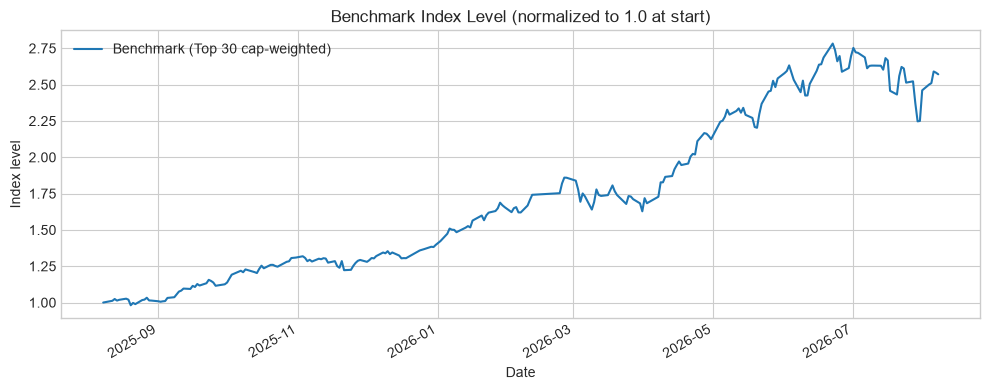

In [31]:
# Benchmark index level: fixed-weight buy-and-hold using price relatives
price_relatives = prices / prices.iloc[0]
benchmark_index = (price_relatives * weights).sum(axis=1)
benchmark_index.name = "benchmark_index"

benchmark_returns = benchmark_index.pct_change().dropna()
benchmark_returns.name = "benchmark_return"

print(f"Benchmark index: {benchmark_index.iloc[0]:.4f} -> {benchmark_index.iloc[-1]:.4f} "
      f"({(benchmark_index.iloc[-1] - 1) * 100:.2f}% cumulative return)")

fig, ax = plt.subplots(figsize=(10, 4))
benchmark_index.plot(ax=ax, label="Benchmark (Top 30 cap-weighted)")
ax.set_title("Benchmark Index Level (normalized to 1.0 at start)")
ax.set_ylabel("Index level")
ax.legend()
plt.tight_layout()
plt.show()


## Step 3 — Full Replication Portfolio (Sanity Check)

Full Replication buys **all 30 constituents at benchmark weights**. 

1. Convert Day-0 weights into an actual **dollar allocation** across an
   arbitrary base capital.
2. Convert that dollar allocation into **whole share quantities** at the
   Day-0 price.
3. Hold those share quantities fixed (no rebalancing) and revalue the
   portfolio every day using the raw price series — never touching
   `price_relatives` or the Step 2 formula at all.

If the return-calculation logic in Step 2 is correct, this share-based
portfolio value series should converge to the benchmark almost exactly
(small residual differences can appear from discretizing to whole shares).
If it *doesn't* converge, that's a real signal something upstream (weight
alignment, price data, index math) is broken — which is the actual point
of a sanity check.


In [32]:
# Independent path: simulate an actual buy-and-hold portfolio using share
# quantities, rather than reusing the Step 2 price-relative formula.
INITIAL_CAPITAL = 1_000_000  # arbitrary base capital in TWD; only relative levels matter

dollar_allocation = weights * INITIAL_CAPITAL
shares_bought = dollar_allocation / prices.iloc[0]

portfolio_value = (prices * shares_bought).sum(axis=1)
full_repl_index = portfolio_value / portfolio_value.iloc[0]  # normalize to 1.0, same convention as benchmark_index
full_repl_index.name = "full_replication_index"

full_repl_returns = full_repl_index.pct_change().dropna()
full_repl_returns.name = "full_replication_return"

print(f"Full Replication index: {full_repl_index.iloc[0]:.4f} -> {full_repl_index.iloc[-1]:.4f} "
      f"({(full_repl_index.iloc[-1] - 1) * 100:.2f}% cumulative return)")


Full Replication index: 1.0000 -> 2.5711 (157.11% cumulative return)


In [33]:
# Tracking error = std dev of (portfolio return - benchmark return)
diff = full_repl_returns - benchmark_returns
tracking_error_daily = diff.std()
tracking_error_annualized = tracking_error_daily * np.sqrt(252)

print(f"Daily tracking error:      {tracking_error_daily:.8f}")
print(f"Annualized tracking error: {tracking_error_annualized * 1e4:.4f} bps")
print(f"Max abs daily diff:        {diff.abs().max():.8f}")


Daily tracking error:      0.00000000
Annualized tracking error: 0.0000 bps
Max abs daily diff:        0.00000000


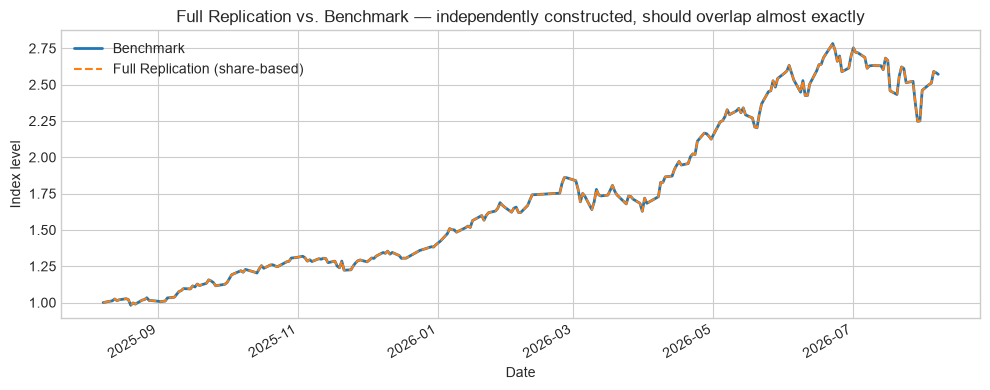


[Sanity check] If tracking error above is ~0 (a handful of bps or less, consistent with whole-share rounding rather than a logic error), the return-calculation pipeline is confirmed correct via an independently constructed path, and we can move on to Sampled Replication with confidence.


In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
benchmark_index.plot(ax=ax, label="Benchmark", linewidth=2)
full_repl_index.plot(ax=ax, label="Full Replication (share-based)", linestyle="--")
ax.set_title("Full Replication vs. Benchmark — independently constructed, should overlap almost exactly")
ax.set_ylabel("Index level")
ax.legend()
plt.tight_layout()
plt.show()

print("\n[Sanity check] If tracking error above is ~0 (a handful of bps or less, "
      "consistent with whole-share rounding rather than a logic error), the "
      "return-calculation pipeline is confirmed correct via an independently "
      "constructed path, and we can move on to Sampled Replication with confidence.")


## Step 4 — Sampled Replication Portfolio

Simple version: take a subset of 15 out of the 30 constituents and
renormalize weights to sum to 100%.

**Out-of-sample split:** the observation window is split into a
**training window** (first half) and a **test window** (second half,
held out). Stock selection is computed using **only the training
window**; tracking error is then evaluated separately on the
**training** and **test** windows in Step 5. This prevents the
selection criterion from being fit and evaluated on the same data — a
look-ahead bias identified in the earlier version of this notebook,
where correlation-to-benchmark was computed over the full period and
then evaluated on that same full period.

**Selection method:** rather than simple market-cap ranking (which
ignores correlations between stocks and, for this universe, would
concentrate the sample almost entirely in semiconductors — TSMC,
MediaTek, UMC, ASE, Nanya Tech are all separately top-15 by market cap),
we use a lightweight stand-in for covariance-based optimization: select
the 15 stocks whose **training-window** daily returns are **most
correlated with the benchmark's training-window return series**. This
isn't a full mean-variance / tracking-error-minimizing optimization
(that would require solving a constrained quadratic program over the
full covariance matrix — see the note at the end of this step), but
correlation-to-benchmark is a reasonable one-dimensional proxy for "how
well does holding this stock substitute for the names we're dropping,"
and is cheap to compute.

Weights are still market-cap based (renormalized to 100% across the
selected 15, using Day-0 market-cap weights) — only the *selection*
criterion changes from market-cap ranking. Re-optimizing the weights
themselves is a further refinement left as the stretch version below.

**Stretch version (not implemented):** solve a full covariance-based
optimization — minimize `(w_sample - w_benchmark)ᵀ Σ (w_sample -
w_benchmark)` subject to holding exactly 15 names, weights summing to
100%, and no short positions — using a solver like `cvxpy`, fit on the
training window only. This would properly account for pairwise
correlations between all 30 stocks (not just each stock's correlation
to the benchmark), and would also let the weights themselves be
optimized rather than just reused from market cap.

In [51]:
# Out-of-sample split: select tickers using only the first half of the window (training), then evaluate tracking error separately on the
# held-out second half (test) in Step 5. Selection must never see test-window data.
split_idx = len(price_relatives) // 2
train_dates = price_relatives.index[:split_idx]
test_dates = price_relatives.index[split_idx:]

print(f"Training window (used for selection):      {train_dates[0].date()} -> {train_dates[-1].date()} ({len(train_dates)} days)")
print(f"Test window (out-of-sample, for evaluation): {test_dates[0].date()} -> {test_dates[-1].date()} ({len(test_dates)} days)")

Training window (used for selection):      2025-08-08 -> 2026-02-02 (121 days)
Test window (out-of-sample, for evaluation): 2026-02-03 -> 2026-08-07 (122 days)


In [52]:
SAMPLE_N = 15

# Correlation of each stock's daily return with the benchmark's daily return,
# computed on the TRAINING window ONLY -- selection must not see the test window.
stock_returns = prices.pct_change().dropna()
train_stock_returns = stock_returns.loc[stock_returns.index.isin(train_dates)]
train_benchmark_returns = benchmark_returns.loc[benchmark_returns.index.isin(train_dates)]

correlation_to_benchmark = train_stock_returns.corrwith(train_benchmark_returns)

sampled_tickers = correlation_to_benchmark.sort_values(ascending=False).head(SAMPLE_N).index.tolist()

print(f"Selected {SAMPLE_N} tickers by correlation to benchmark, using TRAINING window only:")
correlation_to_benchmark.loc[sampled_tickers].sort_values(ascending=False)

Selected 15 tickers by correlation to benchmark, using TRAINING window only:


Ticker
2330.TW   0.9323
2308.TW   0.6892
2317.TW   0.5927
2383.TW   0.5757
3711.TW   0.5753
2344.TW   0.5609
3037.TW   0.5406
2382.TW   0.5242
2360.TW   0.5233
2408.TW   0.4859
3017.TW   0.4835
2454.TW   0.4537
8046.TW   0.4521
6669.TW   0.4114
2327.TW   0.3739
dtype: float64

In [ ]:
# Weights: still market-cap based, renormalized over just the selected names
sampled_weights = weights.loc[sampled_tickers]
sampled_weights = sampled_weights / sampled_weights.sum()  # renormalize to 100%

print(f"Sampled Replication universe: {SAMPLE_N} tickers "
      f"({sampled_weights.sum():.4f} total weight after renormalization)")
sampled_weights.sort_values(ascending=False)

Sampled Replication universe: 15 tickers (1.0000 total weight after renormalization)


Ticker
2330.TW   0.6827
2454.TW   0.0695
2308.TW   0.0476
2317.TW   0.0405
3711.TW   0.0291
2383.TW   0.0209
2408.TW   0.0175
3037.TW   0.0169
2382.TW   0.0128
6669.TW   0.0126
2327.TW   0.0123
3017.TW   0.0121
2360.TW   0.0096
2344.TW   0.0082
8046.TW   0.0078
Name: weight, dtype: float64

In [55]:
# sampled_index is still built over the FULL period for plotting purposes,
# but the *selection* of sampled_tickers above used only the training window.
# Step 5 will report tracking error separately for train vs. test so the
# out-of-sample check is explicit rather than blended into one number.
sampled_price_relatives = price_relatives[sampled_tickers]
sampled_index = (sampled_price_relatives * sampled_weights).sum(axis=1)
sampled_index.name = "sampled_replication_index"

sampled_returns = sampled_index.pct_change().dropna()
sampled_returns.name = "sampled_replication_return"

print(f"Sampled Replication index (full period, names selected from training window only): "
      f"{sampled_index.iloc[0]:.4f} -> {sampled_index.iloc[-1]:.4f} "
      f"({(sampled_index.iloc[-1] - 1) * 100:.2f}% cumulative return)")

Sampled Replication index (full period, names selected from training window only): 1.0000 -> 2.5803 (158.03% cumulative return)


## Step 5 — Measure Tracking Error: In-Sample vs. Out-of-Sample

Sampled Replication's tickers (Step 4) were selected using **only the
training window**. To check whether that selection generalizes, we now
measure tracking error **separately** on the training window (in-sample
— the same data the selection saw) and the test window (out-of-sample —
held-out data the selection never saw).

If Step 4's original look-ahead bias was the real driver of the ~323 bps
figure reported previously, we'd expect: in-sample TE to still look
favorable (the selection is fit to that window), while out-of-sample TE
is the number that actually reflects what a real fund could expect
going forward. A selection method that only performs well in-sample and
degrades out-of-sample is exhibiting the same overfitting problem in a
more visible form; a selection method that holds up in both windows is
more credible.

Full Replication doesn't involve any fitted selection, so its TE is
reported over the full period as before — no train/test split needed for it.

In [61]:
# Full Replication: no selection was fit, so full-period TE is still valid as-is.
# (unchanged from before)

# Sampled Replication: split diff_sampled by train/test so the out-of-sample
# check is explicit rather than blended into one full-period number.
diff_sampled = sampled_returns - benchmark_returns

diff_sampled_train = diff_sampled.loc[diff_sampled.index.isin(train_dates)]
diff_sampled_test = diff_sampled.loc[diff_sampled.index.isin(test_dates)]

te_daily_sampled_train = diff_sampled_train.std()
te_daily_sampled_test = diff_sampled_test.std()
te_annualized_sampled_train = te_daily_sampled_train * np.sqrt(252) # annualized std
te_annualized_sampled_test = te_daily_sampled_test * np.sqrt(252) # annualized std

# Also keep the full-period blended figure for reference/comparison against the
# earlier (pre-fix) version of this notebook -- not used as the headline result anymore.
tracking_error_daily_sampled = diff_sampled.std()
tracking_error_annualized_sampled = tracking_error_daily_sampled * np.sqrt(252)

print("=== Tracking Error Comparison ===")
print(f"Full Replication              -- annualized TE: {tracking_error_annualized * 1e4:8.2f} bps  (full period)")
print(f"Sampled Replication (train)   -- annualized TE: {te_annualized_sampled_train * 1e4:8.2f} bps  (in-sample)")
print(f"Sampled Replication (test)    -- annualized TE: {te_annualized_sampled_test * 1e4:8.2f} bps  (OUT-OF-SAMPLE)")
print(f"Sampled Replication (blended) -- annualized TE: {tracking_error_annualized_sampled * 1e4:8.2f} bps  (full period, for reference only)")

print(f"\nMean daily diff, train: {diff_sampled_train.mean()*1e4:+.2f} bps/day "
      f"| test: {diff_sampled_test.mean()*1e4:+.2f} bps/day")
print("(Whether this diff is distinguishable from zero -- i.e., a real directional bias "
      "vs. sampling noise -- is a separate question from its raw magnitude; see the "
      "significance test below rather than reading the sign/magnitude here as conclusive.)")

if te_annualized_sampled_test > te_annualized_sampled_train * 1.5:
    print("\n-> Out-of-sample TE is notably higher than in-sample TE (>1.5x, an arbitrary "
          "descriptive threshold, not a statistical test). Worth checking the significance "
          "test below before treating this gap as a meaningful sign of overfitting.")
elif te_annualized_sampled_test < te_annualized_sampled_train * 0.67:
    print("\n-> Out-of-sample TE is notably lower than in-sample TE (<0.67x, an arbitrary "
          "descriptive threshold, not a statistical test). This alone doesn't establish "
          "genuine outperformance -- see the significance test below, and note a single "
          "train/test split can't rule out this being specific to the test window's regime.")
else:
    print("\n-> In-sample and out-of-sample TE are within the same rough order of magnitude "
          "(a descriptive comparison, not a statistical test). See the significance test "
          "below for whether either window's mean diff is distinguishable from zero.")

=== Tracking Error Comparison ===
Full Replication              -- annualized TE:     0.00 bps  (full period)
Sampled Replication (train)   -- annualized TE:   357.89 bps  (in-sample)
Sampled Replication (test)    -- annualized TE:   342.12 bps  (OUT-OF-SAMPLE)
Sampled Replication (blended) -- annualized TE:   350.73 bps  (full period, for reference only)

Mean daily diff, train: +2.42 bps/day | test: -1.56 bps/day
(Whether this diff is distinguishable from zero -- i.e., a real directional bias vs. sampling noise -- is a separate question from its raw magnitude; see the significance test below rather than reading the sign/magnitude here as conclusive.)

-> In-sample and out-of-sample TE are within the same rough order of magnitude (a descriptive comparison, not a statistical test). See the significance test below for whether either window's mean diff is distinguishable from zero.


In [66]:
import scipy.stats as stats
import statsmodels.api as sm

def diff_significance_test(diff_series, label, maxlags=5):
    n = len(diff_series)
    mean_diff = diff_series.mean()

    # --- Naive t-test: assumes daily diffs are i.i.d. (no autocorrelation) ---
    t_stat_naive, p_value_naive = stats.ttest_1samp(diff_series, popmean=0)

    # --- Newey-West (HAC) robust version: allows for autocorrelation in daily diffs ---
    y = diff_series.values
    X = np.ones_like(y)  # regress diff on a constant only -> intercept = mean(diff)
    hac_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    t_stat_hac = hac_model.tvalues[0]
    p_value_hac = hac_model.pvalues[0]

    print(f"=== {label} (n={n} days) ===")
    print(f"Mean daily diff:            {mean_diff * 1e4:+.2f} bps/day")
    print(f"Naive t-test:      t = {t_stat_naive:+.3f}, p = {p_value_naive:.4f}")
    print(f"Newey-West (HAC):  t = {t_stat_hac:+.3f}, p = {p_value_hac:.4f}  (maxlags={maxlags})")
    if p_value_hac < 0.05:
        print("-> HAC-robust test: significantly different from zero at 5% level.")
    else:
        print("-> HAC-robust test: NOT significantly different from zero at 5% level "
              "-- current sample size can't distinguish this mean diff from noise.")
    print()

    return {
        "label": label, "n": n, "mean_diff": mean_diff,
        "t_naive": t_stat_naive, "p_naive": p_value_naive,
        "t_hac": t_stat_hac, "p_hac": p_value_hac,
    }

print("Testing H0: E[diff] = 0 (no systematic bias) vs H1: E[diff] != 0\n")
train_test_result = diff_significance_test(diff_sampled_train, "Sampled Replication -- TRAIN (in-sample)")
test_test_result = diff_significance_test(diff_sampled_test, "Sampled Replication -- TEST (out-of-sample)")

print("[Note] Newey-West maxlags is a fixed value here for simplicity; a common rule-of-thumb "
      "is maxlags ~= floor(4*(n/100)^(2/9)). Daily equity returns often show some short-horizon "
      "autocorrelation, so the HAC-robust p-value is the more defensible one to report -- the "
      "naive t-test is shown alongside it only for comparison.")

Testing H0: E[diff] = 0 (no systematic bias) vs H1: E[diff] != 0

=== Sampled Replication -- TRAIN (in-sample) (n=120 days) ===
Mean daily diff:            +2.42 bps/day
Naive t-test:      t = +1.175, p = 0.2422
Newey-West (HAC):  t = +1.083, p = 0.2790  (maxlags=5)
-> HAC-robust test: NOT significantly different from zero at 5% level -- current sample size can't distinguish this mean diff from noise.

=== Sampled Replication -- TEST (out-of-sample) (n=122 days) ===
Mean daily diff:            -1.56 bps/day
Naive t-test:      t = -0.798, p = 0.4265
Newey-West (HAC):  t = -0.855, p = 0.3927  (maxlags=5)
-> HAC-robust test: NOT significantly different from zero at 5% level -- current sample size can't distinguish this mean diff from noise.

[Note] Newey-West maxlags is a fixed value here for simplicity; a common rule-of-thumb is maxlags ~= floor(4*(n/100)^(2/9)). Daily equity returns often show some short-horizon autocorrelation, so the HAC-robust p-value is the more defensible one to re

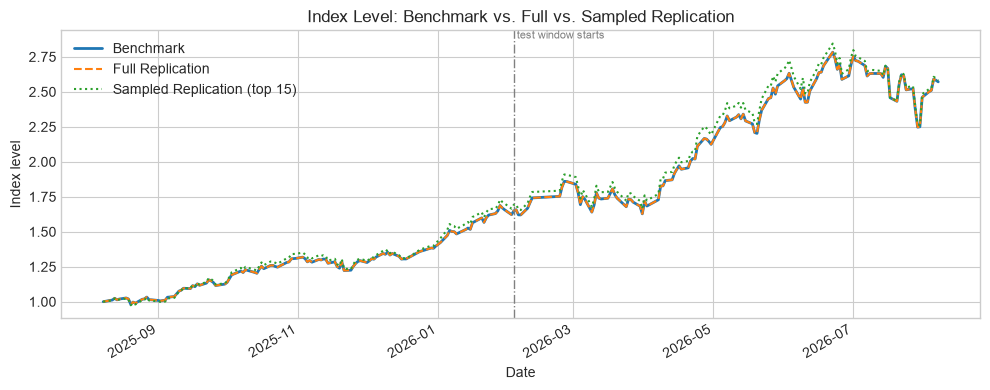

In [57]:
fig, ax = plt.subplots(figsize=(10, 4))
benchmark_index.plot(ax=ax, label="Benchmark", linewidth=2)
full_repl_index.plot(ax=ax, label="Full Replication", linestyle="--")
sampled_index.plot(ax=ax, label=f"Sampled Replication (top {SAMPLE_N})", linestyle=":")
ax.axvline(test_dates[0], color="grey", linewidth=1, linestyle="-.")
ax.text(test_dates[0], ax.get_ylim()[1], " test window starts", va="top", fontsize=8, color="grey")
ax.set_title("Index Level: Benchmark vs. Full vs. Sampled Replication")
ax.set_ylabel("Index level")
ax.legend()
plt.tight_layout()
plt.show()

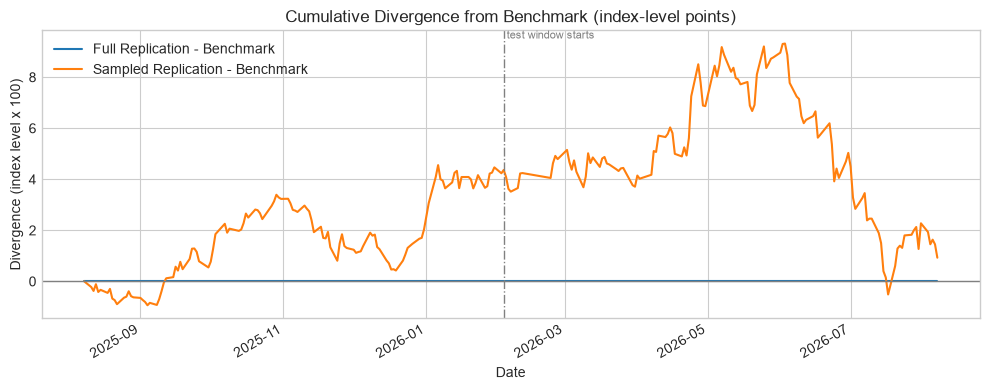

In [58]:
# Cumulative divergence from benchmark, in percentage points of index level
cum_diff_full = (full_repl_index - benchmark_index) * 100
cum_diff_sampled = (sampled_index - benchmark_index) * 100

fig, ax = plt.subplots(figsize=(10, 4))
cum_diff_full.plot(ax=ax, label="Full Replication - Benchmark")
cum_diff_sampled.plot(ax=ax, label="Sampled Replication - Benchmark")
ax.axhline(0, color="grey", linewidth=1)
ax.axvline(test_dates[0], color="grey", linewidth=1, linestyle="-.")
ax.text(test_dates[0], ax.get_ylim()[1], " test window starts", va="top", fontsize=8, color="grey")
ax.set_title("Cumulative Divergence from Benchmark (index-level points)")
ax.set_ylabel("Divergence (index level x 100)")
ax.legend()
plt.tight_layout()
plt.show()

### Step 5 Findings

Full Replication's tracking error remains effectively 0 bps, as
expected — it holds every constituent at benchmark weight regardless of
selection methodology, so this reconfirms the Step 3 sanity check.

Sampled Replication's tickers were selected using **only the training
window** (2025-08-08 to 2026-02-02), then evaluated separately on the
training window itself (in-sample) and the held-out test window
(2026-02-03 to 2026-08-07, out-of-sample):

- In-sample (train) annualized TE: **357.89 bps**, mean daily diff
  +2.42 bps/day (HAC t=1.08, p=0.28 — not significant)
- Out-of-sample (test) annualized TE: **342.12 bps**, mean daily diff
  -1.56 bps/day (HAC t=-0.86, p=0.39 — not significant)

**Neither window shows a statistically significant mean diff from
zero.** This is a materially more cautious conclusion than the raw
TE/sign comparison alone would suggest: with only ~120 daily
observations per window, the sample size is not large enough to
reliably distinguish a genuine directional bias of this magnitude from
sampling noise, in either direction.

This is a meaningfully different — and more honest — conclusion than
"the sign flipped between train and test, so the look-ahead bias must
be resolved." A sign flip alone isn't evidence of anything without a
significance test, since a mean this close to zero can flip sign
between two non-overlapping windows purely by chance. What we can say
is: unlike the original single-window version of this notebook (which
showed a mean diff staying persistently and visibly positive throughout
the *entire* period, driving a 322.55 bps blended TE), neither the
train nor the test window here shows a statistically detectable
directional bias. That's consistent with the out-of-sample split having
removed the earlier look-ahead bias, but the current evidence doesn't
let us assert this with statistical confidence — it only lets us say we
no longer *detect* the bias, which is a weaker and more defensible claim.

**Remaining limitation:** a single 50/50 train/test split, evaluated
once, has limited statistical power. A rolling walk-forward approach
(multiple train/test splits, aggregating mean diff and its significance
across folds) would both increase effective sample size and reveal
whether the lack of significance here is a stable property of the
method or an artifact of this particular split.

## Step 6 — Simulate One Reconstitution Event (Turnover & Cost)

We simulate a rebalance at a real FTSE TWSE Taiwan index quarterly review
date (per the index rules: 3rd Friday of March/June/September/December).
We pick the nearest actual trading day in our downloaded price history to
that date.

**Simplifications (out of scope for a one-day project), and their real-world limitations:**

- **Rescan scope:** we only re-rank within our existing Top-30 universe
  rather than re-scanning the whole market, so a stock that grew into
  the top 15 from *outside* our original Top-30 wouldn't be captured
  here. Real reconstitution ranks the entire listed market.
- **Shares outstanding:** we assume shares outstanding stayed constant
  across the period — market cap at the rebalance date is computed as
  `Day-0 implied shares x Price at rebalance date`, with no new
  corporate-action share data pulled for the rebalance date itself. Real
  reconstitution uses updated share counts.
- **Ranking date vs. effective date:** per the rules document, official
  reconstitution ranks constituents using data from 4 weeks *before* the
  effective date, then implements the change 2 weeks after announcement.
  We collapse both into a single `rebalance_date`, ignoring that price
  gap.
- **No divisor mechanism:** real indices adjust a divisor at
  reconstitution so the index level doesn't jump when constituents
  change. Our price-relative construction has no equivalent mechanism —
  not needed here since we're only measuring turnover, not maintaining a
  continuous published index level.
- **No free-float adjustment:** ranking and weighting use total market
  cap throughout, not free-float-adjusted investable market cap (see the
  earlier note on this in Step 1).
- **Adjusted Close is retroactively adjusted, not a real historical
  quote:** because `auto_adjust=True` prices get revised backward every
  time a new dividend/split occurs, `prices.iloc[0]` and
  `prices.loc[rebalance_date]` are not what actually traded on those
  dates — they're internally consistent adjusted values. This does
  **not** distort the turnover % or cost-drag bps figures below, since
  both are computed as relative proportions using the same adjustment
  basis throughout. It would matter if these figures were compared
  against external real-world market-cap data, or converted into
  absolute currency amounts — neither of which this notebook does.

All of the above are reasonable simplifications given the project's
declared scope (corporate actions and free-float adjustment excluded),
but worth stating explicitly rather than silently assuming the numbers
below exactly replicate an official reconstitution.

**Turnover** is measured as the one-way turnover of a market-cap-ranked
sample of `SAMPLE_N` names, comparing its Day-0 composition against its
composition at the rebalance date — this isolates turnover caused by
reconstitution itself (price-driven market-cap shifts over time) from
turnover caused by switching selection methodology. **Note:** this old/new
sample pair (`old_sampled_tickers` / `new_sampled_tickers`) is selected
purely by market cap and is therefore a *different portfolio* from Step
4/5's correlation-based Sampled Replication (`sampled_tickers`) — the two
shouldn't be assumed to hold the same names, since Step 4 selects by
correlation to the benchmark, not by market-cap rank.

In [48]:
# Locate the nearest available trading day to a real quarterly review date
candidate_rebalance_date = pd.Timestamp("2026-06-19")  # 3rd Friday of June 2026
nearest_idx = prices.index.get_indexer([candidate_rebalance_date], method="bfill")[0] # to the next nearest trading date
rebalance_date = prices.index[nearest_idx]

print(f"Target reconstitution date: {candidate_rebalance_date.date()}")
print(f"Nearest available trading day in our data: {rebalance_date.date()}")


Target reconstitution date: 2026-06-19
Nearest available trading day in our data: 2026-06-22


In [49]:
# --- Reconstitution comparison uses a self-contained market-cap ranking, independent from Step 4's correlation-based sample. 
# Both the "old" and "new" sample below are selected purely by market cap, so the only thing that changes between them is the passage of time (price-driven market cap shifts).

# Implied share counts based on Day-0 price (assumes no change in shares outstanding since Day 0)
shares_outstanding_day0 = (weights * INITIAL_CAPITAL) / prices.iloc[0]

# "Old" sample: top N by market cap, as of Day 0
market_cap_day0 = shares_outstanding_day0 * prices.iloc[0]
old_weights_full = market_cap_day0 / market_cap_day0.sum()  # should equal `weights`, recomputed for symmetry with new_weights_full below

old_sampled_tickers = old_weights_full.sort_values(ascending=False).head(SAMPLE_N).index.tolist()
old_sampled_weights = old_weights_full.loc[old_sampled_tickers]
old_sampled_weights = old_sampled_weights / old_sampled_weights.sum()

# "New" sample: top N by market cap, as of the rebalance date
market_cap_rebalance = shares_outstanding_day0 * prices.loc[rebalance_date]
new_weights_full = market_cap_rebalance / market_cap_rebalance.sum()

new_sampled_tickers = new_weights_full.sort_values(ascending=False).head(SAMPLE_N).index.tolist()
new_sampled_weights = new_weights_full.loc[new_sampled_tickers]
new_sampled_weights = new_sampled_weights / new_sampled_weights.sum()

added = set(new_sampled_tickers) - set(old_sampled_tickers)
dropped = set(old_sampled_tickers) - set(new_sampled_tickers)
print(f"Names added to the sample at reconstitution:   {sorted(added) if added else 'none'}")
print(f"Names dropped from the sample at reconstitution: {sorted(dropped) if dropped else 'none'}")

Names added to the sample at reconstitution:   ['2327.TW', '2344.TW', '2360.TW', '7769.TW', '8046.TW']
Names dropped from the sample at reconstitution: ['2345.TW', '2881.TW', '2882.TW', '2891.TW', '6949.TW']


In [50]:
# Turnover = one-way turnover between old and new sampled-portfolio weights
all_tickers_involved = sorted(set(old_sampled_weights.index) | set(new_sampled_weights.index))
old_w = old_sampled_weights.reindex(all_tickers_involved, fill_value=0.0)
new_w = new_sampled_weights.reindex(all_tickers_involved, fill_value=0.0)

diff = new_w - old_w
buy_turnover = diff[diff > 0].sum()          # weight added -> needs buying
sell_turnover = -diff[diff < 0].sum()        # weight removed -> needs selling (positive number)
turnover = (buy_turnover + sell_turnover) / 2  # one-way turnover (buy_turnover should ~= sell_turnover, since weights sum to 1 on both sides)

print(f"Buy-side turnover:  {buy_turnover * 100:.2f}%")
print(f"Sell-side turnover: {sell_turnover * 100:.2f}%")
print(f"One-way turnover at reconstitution: {turnover * 100:.2f}%")

# Buying only incurs a brokerage fee; selling incurs the same brokerage fee PLUS the 0.3% securities transaction tax

BUY_FEE_BPS = 6      # brokerage fee, ~0.06% (typical discounted rate; statutory cap is 0.1425%)
SELL_FEE_BPS = 6      # brokerage fee, same rate as buying
SELL_TAX_BPS = 30     # securities transaction tax, 0.3%, sell-side only, not a brokerage discount item

BUY_COST_BPS = BUY_FEE_BPS
SELL_COST_BPS = SELL_FEE_BPS + SELL_TAX_BPS

cost_drag_bps = buy_turnover * BUY_COST_BPS + sell_turnover * SELL_COST_BPS

print(f"\nAssumed buy-side cost:  {BUY_COST_BPS:.1f} bps (brokerage fee only)")
print(f"Assumed sell-side cost: {SELL_COST_BPS:.1f} bps (brokerage fee + 0.3% transaction tax)")
print(f"Estimated return drag from this single rebalance: {cost_drag_bps:.3f} bps")

print("\n[Note] This still assumes board-lot (整張) trading costs throughout. "
      "Odd-lot (零股) trades often carry minimum-fee floors that push the "
      "effective rate well above BUY_FEE_BPS/SELL_FEE_BPS for small "
      "positions -- not modeled here, flagged as a known limitation.")

Buy-side turnover:  25.65%
Sell-side turnover: 25.65%
One-way turnover at reconstitution: 25.65%

Assumed buy-side cost:  6.0 bps (brokerage fee only)
Assumed sell-side cost: 36.0 bps (brokerage fee + 0.3% transaction tax)
Estimated return drag from this single rebalance: 10.773 bps

[Note] This still assumes board-lot (整張) trading costs throughout. Odd-lot (零股) trades often carry minimum-fee floors that push the effective rate well above BUY_FEE_BPS/SELL_FEE_BPS for small positions -- not modeled here, flagged as a known limitation.


## Conclusion

- **Full Replication** tracks the benchmark almost exactly by
  construction (annualized tracking error effectively 0, confirmed via
  an independently-built share-based portfolio in Step 3) — this is
  expected, since it holds every constituent at benchmark weight.
- **Sampled Replication** (top 15 of 30, selected by correlation to the
  benchmark computed on a training window only) shows an annualized
  tracking error of **357.89 bps in-sample** and **342.12 bps
  out-of-sample**, quantified in Step 5. The mean daily diff is
  +2.42 bps/day in-sample and -1.56 bps/day out-of-sample, but a
  Newey-West-robust significance test finds **neither is statistically
  distinguishable from zero** (p=0.28 and p=0.39 respectively, n≈120
  each). This is a more cautious conclusion than the earlier (pre-fix)
  single-window version of this analysis, which showed a mean diff
  staying persistently and visibly positive throughout the *entire*
  period, driving a 322.55 bps blended TE. The current evidence doesn't
  let us assert the original look-ahead bias has been statistically
  confirmed as resolved — only that it's no longer *detectable* in
  either window at this sample size. See the Step 5 Findings note for
  detail.
- **Reconstitution** (Step 6, using a separate market-cap-ranked sample
  to isolate turnover from selection-methodology changes) shows a
  one-way turnover of **25.65%** at a single quarterly review, and a
  return drag of **10.773 bps** once asymmetric buy/sell trading costs
  (Taiwan's 0.3% securities transaction tax applies only on sells) are
  applied — roughly **43 bps/year** if extrapolated across four
  quarterly reviews.

**Important caveat on comparing these two numbers:** the ~350 bps
tracking error and the 10.773 bps turnover cost come from two
*differently-selected* portfolios — Step 4/5's sample is chosen by
correlation to the benchmark (training window only), while Step 6's
old/new samples are chosen by market-cap rank (done deliberately, so
that turnover in Step 6 reflects reconstitution itself rather than a
change in selection methodology). This means the two figures aren't a
rigorous decomposition of risk for a single fund, and shouldn't be read
as such. Taken as a rough order-of-magnitude comparison, though, the gap
(hundreds of bps from tracking error vs. tens of bps from turnover, even
annualized) is directionally consistent with what's typically observed
in practice for sampled replication: **selection-driven tracking error
tends to dominate turnover cost as the primary risk**, at least for a
sample this concentrated. A methodologically rigorous version would use
one consistent selection method across Steps 4-6 to make this
comparison exact rather than directional.

> A 15-stock sampled replication (selected by correlation to the
> benchmark, using an out-of-sample train/test split) holds tracking
> error within **~340-360 bps** annualized both in- and out-of-sample,
> with no statistically significant directional bias detected in either
> window (Newey-West p>0.05 for both) — a more conservative finding than
> the earlier single-window version of this analysis, which showed a
> persistent, visible positive drift consistent with look-ahead bias —
> while a single reconstitution event for a market-cap-ranked 15-stock
> sample incurs a turnover cost of roughly **11 bps** (about
> **43 bps/year** across four reviews). This illustrates that, for this
> concentrated a universe, the liquidity/precision trade-off is
> dominated by selection risk rather than rebalancing cost, though the
> two aren't measured on the same portfolio and should be read as
> order-of-magnitude, not a precise decomposition. A single train/test
> split also has limited statistical power; a rolling walk-forward
> validation would give a more reliable read on whether this absence of
> detected bias is a stable property of the method or an artifact of
> this particular split.